### Imports

In [141]:
import warnings
warnings.filterwarnings('ignore')

import sys
import subprocess
import importlib

def _ensure(package_name: str, import_name: str = None):
    """
    Ensure a package is importable. If not present, install with pip.
    package_name: name to pass to pip (e.g. "scikit-learn")
    import_name: module name to import (e.g. "sklearn"). If None, use package_name.
    """
    mod_name = import_name or package_name
    try:
        importlib.import_module(mod_name)
        return False
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()
        importlib.import_module(mod_name)
        return True

_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "nltk": "nltk",
    "openpyxl": "openpyxl",
    "gensim": "gensim",
    "statsmodels": "statsmodels",
    "xgboost": "xgboost",
    "pickle": "pickle"
}

_installed = {}
for module_name, pip_name in _packages.items():
    _installed[module_name] = _ensure(pip_name, module_name)


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from gensim.models import Word2Vec

from xgboost import XGBClassifier

import re
import pickle

# Download required NLTK resources (quiet)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

True

### Helper Functions

In [142]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str, remove_stopwords: bool = True) -> str:
    # Normalize whitespace and lowercase
    s = " ".join(str(text).split()).lower()

    # Remove URLs & email/user mentions
    s = re.sub(r'http\S+|www\S+|@\S+', '', s)

    # Remove special characters, punctuation, and numbers (keep letters and spaces)
    s = re.sub(r'[^a-zA-Z\s]', ' ', s)

    # Tokenize
    tokens = word_tokenize(s)

    # Remove stopwords & lemmatize (or just lemmatize if remove_stopwords=False)
    if remove_stopwords:
        tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

def load_lf_xlsx(xlsx_path: str) -> pd.DataFrame:
    xl = pd.read_excel(xlsx_path)
    
    X = xl.drop(columns=['label'])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lf = pd.DataFrame(X_scaled, columns=X.columns)

    return lf.reset_index(drop=True) 

In [143]:
# checking dataset potential issues
def check_dataset(word_embeddings, linguistic_features, combined_features, y_train):
    print(f"Word embeddings shape: {word_embeddings.shape}")
    print(f"Linguistic features shape: {linguistic_features.shape}")
    print(f"Combined features shape: {combined_features.shape}")
    print(f"Training samples: {len(y_train)}")
    print(f"Total features: {combined_features.shape[1]}")
    print(f"Features vs Samples ratio: {combined_features.shape[1] / len(y_train):.2f}")

    # Check for potential issues
    print("\nChecking for potential multicollinearity issues:")
    print(f"Any NaN values: {np.isnan(combined_features).any()}")
    print(f"Any infinite values: {np.isinf(combined_features).any()}")

    # Check feature variance
    feature_variances = np.var(combined_features, axis=0)
    low_variance_features = np.sum(feature_variances < 1e-10)
    print(f"Features with very low variance (< 1e-10): {low_variance_features}")

    # Check condition number (indicates multicollinearity)
    try:
        cond_number = np.linalg.cond(combined_features)
        print(f"Condition number: {cond_number:.2e}")
        if cond_number > 1e12:
            print("High condition number suggests severe multicollinearity")
    except:
        print("Could not compute condition number - likely singular matrix")

In [144]:
# logistic regression model with grid search and cross-validation
def train_logistic_regression(X_train, y_train, model_name):
    # check if model already exists in all_models/ folder
    try:
        with open(f'all_models/{model_name}_logistic_regression.pkl', 'rb') as f:
            model = pickle.load(f)
            print(f"Loaded existing model from all_models/{model_name}_logistic_regression.pkl")
            return model
    except FileNotFoundError:
        print("No existing model found, training a new one...")
        param_grid = {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2']
        }

        lr = LogisticRegression(max_iter=1000, random_state=42)
        grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        best_model = grid_search.best_estimator_
        with open(f'all_models/{model_name}_logistic_regression.pkl', 'wb') as f:
            pickle.dump(best_model, f)
            print(f"Saved model to all_models/{model_name}_logistic_regression.pkl")
        return best_model

In [145]:
# svm model with grid search and cross-validation
def train_svm(X_train, y_train, model_name):
    # check if model already exists in all_models/ folder
    try:
        with open(f'all_models/{model_name}_svm.pkl', 'rb') as f:
            model = pickle.load(f)
            print(f"Loaded existing model from all_models/{model_name}_svm.pkl")
            return model
    except FileNotFoundError:
        print("No existing model found, training a new one...")
        param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }

        svm = SVC(random_state=42)
        grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        best_model = grid_search.best_estimator_
        
        # saving the best model
        with open(f'all_models/{model_name}_svm.pkl', 'wb') as f:
            pickle.dump(best_model, f)
            print(f"Saved model to all_models/{model_name}_svm.pkl")
        return best_model

In [146]:
# xgboost classifier with grid search and cross-validation
def train_xgboost(X_train, y_train, model_name):
    # check if model already exists in all_models/ folder
    try:
        with open(f'all_models/{model_name}_xgboost.pkl', 'rb') as f:
            model = pickle.load(f)
            print(f"Loaded existing model from all_models/{model_name}_xgboost.pkl")
            return model
    except FileNotFoundError:
        print("No existing model found, training a new one...")
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        }

        xgb = XGBClassifier(random_state=42, eval_metric='logloss')
        grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        best_model = grid_search.best_estimator_
        
        with open(f'all_models/{model_name}_xgboost.pkl', 'wb') as f:
            pickle.dump(best_model, f)
            print(f"Saved model to all_models/{model_name}_xgboost.pkl")

        return best_model

In [147]:
# model evaluation function
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

### Datasets

#### Dataset Loader

In [148]:
def load_dataset(csv_path: str, lf_path: str):
    df = pd.read_csv(csv_path)

    # taking only text and label columns, dropping rows with missing values
    df = df[["text", "label"]].dropna()

    # Preprocess text: normalize, remove stopwords, lemmatize
    df["clean_text"] = df["text"].map(lambda s: preprocess(s, remove_stopwords=True))

    # Tokenized sentences
    tokenized_sentences = df["clean_text"].apply(lambda x: x.split())

    # Labels
    y = df["label"].astype(int)

    # Linguistic features
    lf = load_lf_xlsx(lf_path)

    # Drop original label columns
    df = df.drop(columns=["label"])

    return {
        "tokenized_sentences": tokenized_sentences,
        "dataset": df,
        "output_labels": y,
        "linguistic_features": lf
    }

In [149]:
def create_train_test_split(X_data, y_data, random_state=42, test_size = 0.3):
    return train_test_split(X_data, y_data, test_size=test_size, random_state=random_state)

#### Mcintire Dataset

In [150]:
mcinter_dataset_path = "Dataset/Mcintire_DataSet.csv"
mcinter_lf_path = "Dataset/linguistic_features/arrays_Mcintire.xlsx"

mcinter_data = load_dataset(mcinter_dataset_path, mcinter_lf_path)

mcinter_df = mcinter_data["dataset"]
mcinter_y = mcinter_data["output_labels"]
mcinter_lf = mcinter_data["linguistic_features"]
mcinter_tokenized = mcinter_data["tokenized_sentences"]

mcinter_df.shape, mcinter_y.shape, mcinter_lf.shape, mcinter_tokenized.shape

((6335, 2), (6335,), (6335, 80), (6335,))

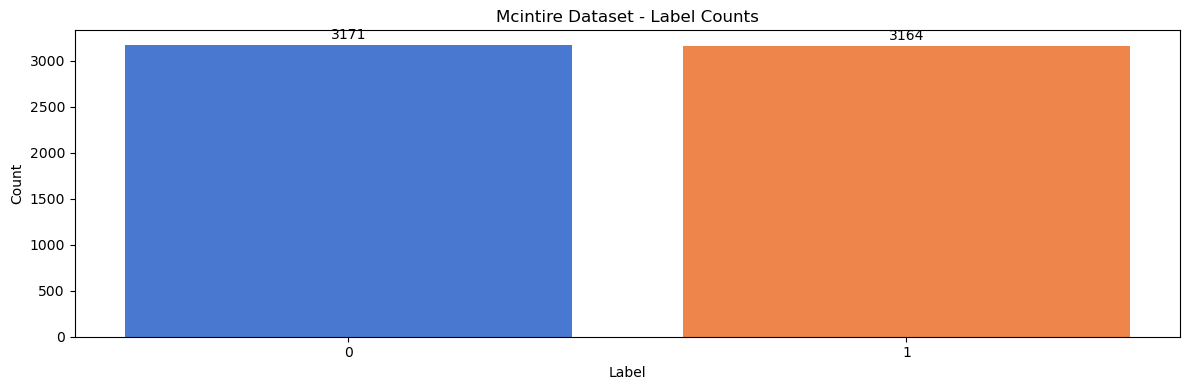

In [151]:
counts = mcinter_y.value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# Bar plot
colors = sns.color_palette("muted", n_colors=len(counts))
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_title("Mcintire Dataset - Label Counts")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [152]:
# Word2Vec model training and embedding extraction

mcinter_word2vec = Word2Vec(sentences=mcinter_tokenized, vector_size=100, window=5, min_count=1, workers=4)

mcinter_word_embeddings = np.array([np.mean([mcinter_word2vec.wv[word] for word in words if word in mcinter_word2vec.wv] or [np.zeros(100)], axis=0) for words in mcinter_tokenized])

In [153]:
# train-test split with combined features

X_combined = np.concatenate((mcinter_word_embeddings, mcinter_lf.values), axis=1)

X_train, X_test, y_train, y_test = create_train_test_split(X_combined, mcinter_y, random_state=42, test_size=0.3)

In [154]:
# checking the dimensions and potential issues
check_dataset(mcinter_word_embeddings, mcinter_lf, X_combined, y_train)

Word embeddings shape: (6335, 100)
Linguistic features shape: (6335, 80)
Combined features shape: (6335, 180)
Training samples: 4434
Total features: 180
Features vs Samples ratio: 0.04

Checking for potential multicollinearity issues:
Any NaN values: False
Any infinite values: False
Features with very low variance (< 1e-10): 1
Condition number: 5.40e+19
High condition number suggests severe multicollinearity


##### Logistic Regression

In [155]:
mcinter_logit_model = train_logistic_regression(X_train, y_train, model_name="mcinter")

Loaded existing model from all_models/mcinter_logistic_regression.pkl


Accuracy: 0.9200
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       933
           1       0.90      0.94      0.92       968

    accuracy                           0.92      1901
   macro avg       0.92      0.92      0.92      1901
weighted avg       0.92      0.92      0.92      1901



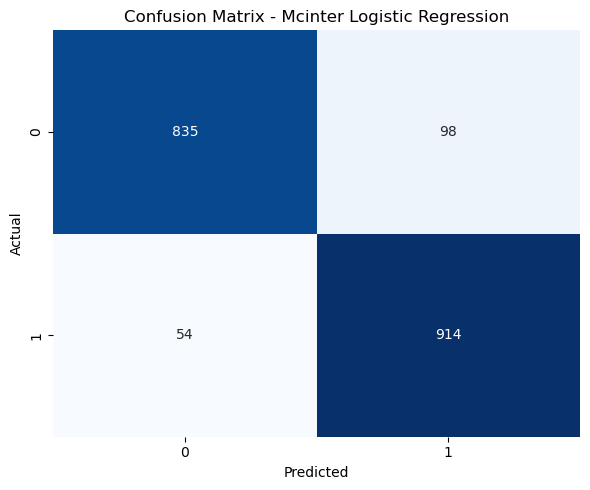

In [156]:
evaluate_model(mcinter_logit_model, X_test, y_test, model_name="Mcinter Logistic Regression")

##### SVM

In [157]:
mcinter_svm_model = train_svm(X_train, y_train, model_name="mcinter")

Loaded existing model from all_models/mcinter_svm.pkl


Accuracy: 0.9327
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       933
           1       0.92      0.96      0.94       968

    accuracy                           0.93      1901
   macro avg       0.93      0.93      0.93      1901
weighted avg       0.93      0.93      0.93      1901



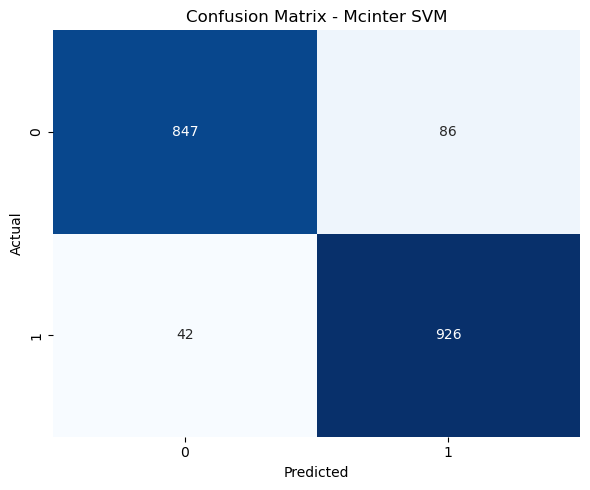

In [158]:
evaluate_model(mcinter_svm_model, X_test, y_test, model_name="Mcinter SVM")

##### XGBoost

In [159]:
mcinter_xgb_model = train_xgboost(X_train, y_train, model_name="mcinter")

Loaded existing model from all_models/mcinter_xgboost.pkl


Accuracy: 0.9379
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       933
           1       0.92      0.96      0.94       968

    accuracy                           0.94      1901
   macro avg       0.94      0.94      0.94      1901
weighted avg       0.94      0.94      0.94      1901



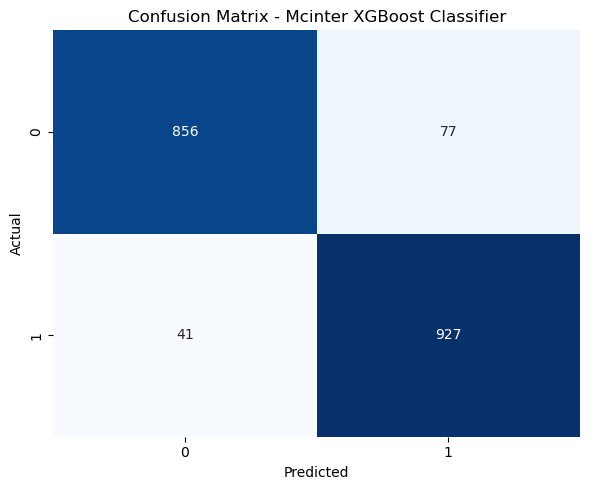

In [160]:
evaluate_model(mcinter_xgb_model, X_test, y_test, model_name="Mcinter XGBoost Classifier")

#### Kaggle Dataset

In [161]:
kaggle_dataset_path = "Dataset/Kaggle.csv"
kaggle_lf_path = "Dataset/linguistic_features/arrays_kaggle.xlsx"

kaggle_data = load_dataset(kaggle_dataset_path, kaggle_lf_path)

kaggle_df = kaggle_data["dataset"]
kaggle_y = kaggle_data["output_labels"]
kaggle_lf = kaggle_data["linguistic_features"]
kaggle_tokenized = kaggle_data["tokenized_sentences"]

kaggle_df.shape, kaggle_y.shape, kaggle_lf.shape, kaggle_tokenized.shape

((20761, 2), (20761,), (20761, 80), (20761,))

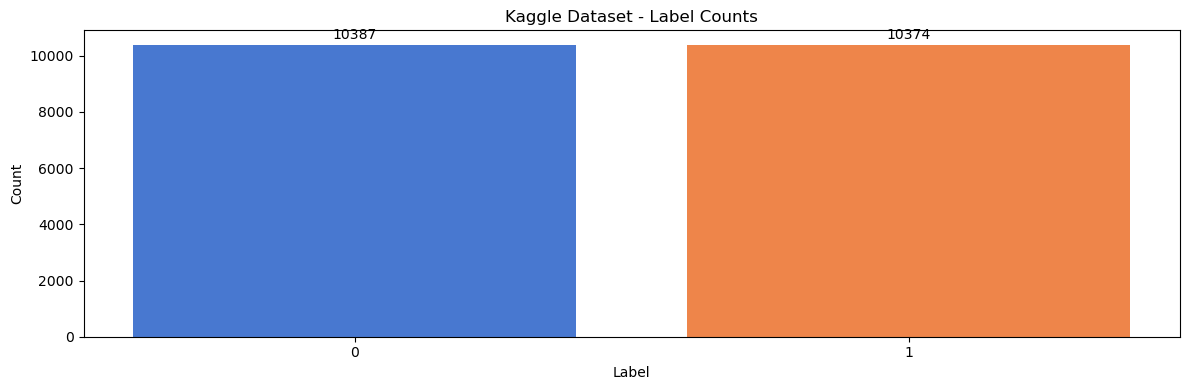

In [162]:
counts = kaggle_y.value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# Bar plot
colors = sns.color_palette("muted", n_colors=len(counts))
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_title("Kaggle Dataset - Label Counts")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [163]:
# Word2Vec model training and embedding extraction
kaggle_word2vec = Word2Vec(sentences=kaggle_tokenized, vector_size=100, window=5, min_count=1, workers=4)

kaggle_word_embeddings = np.array([np.mean([kaggle_word2vec.wv[word] for word in words if word in kaggle_word2vec.wv] or [np.zeros(100)], axis=0) for words in kaggle_tokenized])

In [164]:
# train-test split with combined features

X_combined = np.concatenate((kaggle_word_embeddings, kaggle_lf.values), axis=1)

X_train, X_test, y_train, y_test = create_train_test_split(X_combined, kaggle_y, random_state=42, test_size=0.3)

In [165]:
# checking the dimensions and potential issues
check_dataset(kaggle_word_embeddings, kaggle_lf, X_combined, y_train)

Word embeddings shape: (20761, 100)
Linguistic features shape: (20761, 80)
Combined features shape: (20761, 180)
Training samples: 14532
Total features: 180
Features vs Samples ratio: 0.01

Checking for potential multicollinearity issues:
Any NaN values: False
Any infinite values: False
Features with very low variance (< 1e-10): 1
Condition number: 7.84e+17
High condition number suggests severe multicollinearity


##### Logistic Regression

In [166]:
kaggle_logit_model = train_logistic_regression(X_train, y_train, model_name="kaggle")

Loaded existing model from all_models/kaggle_logistic_regression.pkl


Accuracy: 0.9250
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      3138
           1       0.87      1.00      0.93      3091

    accuracy                           0.93      6229
   macro avg       0.93      0.93      0.92      6229
weighted avg       0.93      0.93      0.92      6229



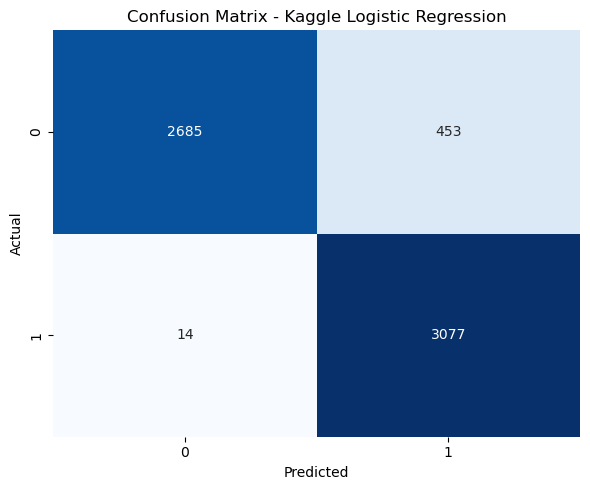

In [167]:
evaluate_model(kaggle_logit_model, X_test, y_test, model_name="Kaggle Logistic Regression")

##### SVM

In [168]:
kaggle_svm_model = train_svm(X_train, y_train, model_name="kaggle")

Loaded existing model from all_models/kaggle_svm.pkl


Accuracy: 0.9518
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      3138
           1       0.92      0.99      0.95      3091

    accuracy                           0.95      6229
   macro avg       0.95      0.95      0.95      6229
weighted avg       0.95      0.95      0.95      6229



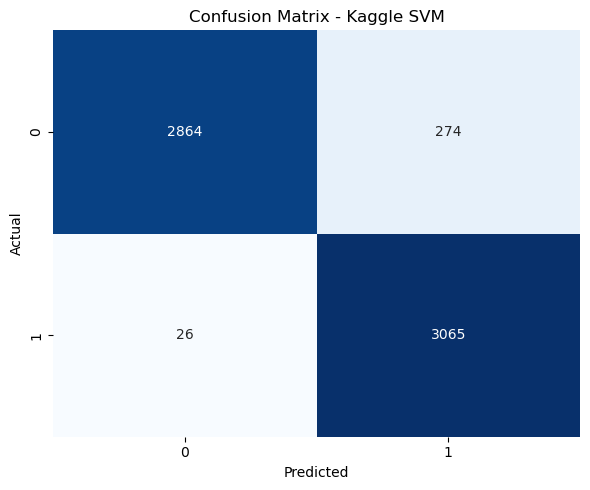

In [169]:
evaluate_model(kaggle_svm_model, X_test, y_test, model_name="Kaggle SVM")

##### XGBoost

In [170]:
kaggle_xgb_model = train_xgboost(X_train, y_train, model_name="kaggle")

Loaded existing model from all_models/kaggle_xgboost.pkl


Accuracy: 0.9838
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3138
           1       0.99      0.98      0.98      3091

    accuracy                           0.98      6229
   macro avg       0.98      0.98      0.98      6229
weighted avg       0.98      0.98      0.98      6229



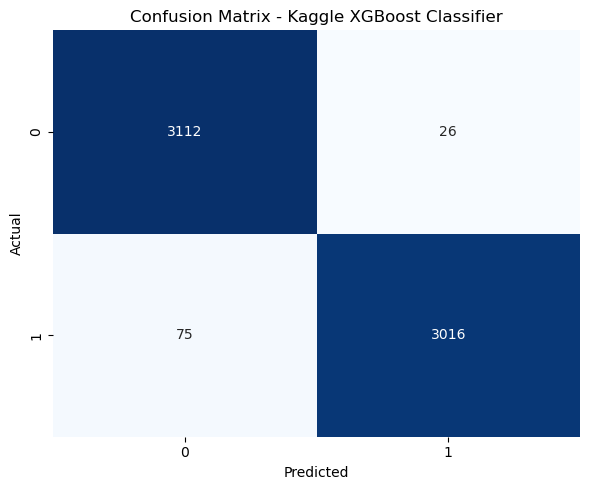

In [171]:
evaluate_model(kaggle_xgb_model, X_test, y_test, model_name="Kaggle XGBoost Classifier")